# MATH 360 Python Assignment 3

* See [Mathematical Python](https://patrickwalls.github.io/mathematicalpython/) for an introduction to Python and Jupyter
* See [Introduction to Mathematical Modelling](https://ubcmath.github.io/MATH360/) for more examples
* Write solutions in the cells with `YOUR CODE HERE`
* Do **not** import any packages (other than the standard packages in the cell below)
* Run the tests to verify your solutions
* There are **hidden tests** therefore your solutions may not be entirely correct even if they pass the tests below
* Submit your `.ipynb` notebook file to Canvas (download from Syzygy to your machine and upload to Canvas)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

## Problem 1: Linear Regression

Let us recall the formulation of linear regression (see [MATH 360 > Data-Driven Models > Linear Regression](https://ubcmath.github.io/MATH360/data-driven/linear-regression/least-squares.html#normal-equations)). Consider $N+1$ data points $(x_0,y_0),(x_1,y_1),\dots,(x_N,y_N)$. The linear model $y = \beta_0 + \beta_1 x + \varepsilon$ that best fits the data is the solution to the normal equations

$$
X^T X \boldsymbol{\beta} = X^T \boldsymbol{y}
$$

where

$$
X = \begin{bmatrix} 1 & x_0 \\ 1 & x_1 \\ \vdots & \vdots \\ 1 & x_N \end{bmatrix}
\hspace{10mm}
\boldsymbol{y} = \begin{bmatrix} y_0 \\ y_1 \\ \vdots \\ y_N \end{bmatrix}
\hspace{10mm}
\boldsymbol{\beta} = \begin{bmatrix} \beta_0 \\ \beta_1 \end{bmatrix}
$$

The vector of coefficients $\boldsymbol{\beta}$ minimizes the residual sum of squares

$$
\| \boldsymbol{y} - X \boldsymbol{\beta} \|^2
$$

Consider the following data:

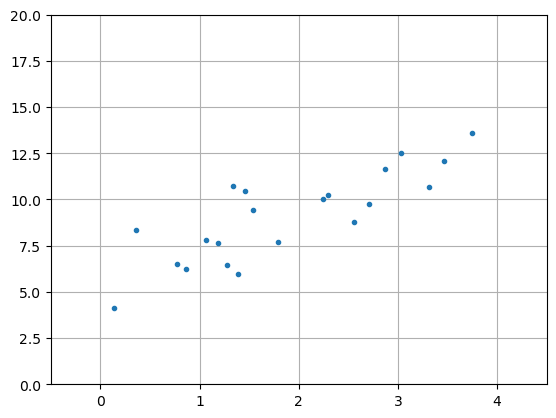

In [2]:
x1 = [ 1.19, 3.75, 0.36, 3.03, 3.46, 0.77, 0.14, 1.54, 1.46, 2.87, 1.79, 0.86, 1.34, 1.39, 1.28, 1.07, 2.3 , 3.31, 2.24, 2.71, 2.56]
y1 = [ 7.62,13.58, 8.34,12.54,12.08, 6.52, 4.15, 9.45,10.45,11.67, 7.70, 6.25,10.74, 5.96, 6.48, 7.83,10.26,10.65,10.01, 9.77, 8.80]
plt.plot(x1,y1,'.')
plt.grid(True), plt.xlim([-0.5,4.5]), plt.ylim([0,20])
plt.show()

### Part 1a (2 marks)

Compute the matrix multiplication $X^TX$ for the data `x1` above. Save the result as `XTX1a`.

In [3]:
# YOUR CODE HERE
X = np.array(np.column_stack((np.ones(len(x1)), x1)))

XTX1a = X.T @ X
XTX1a


array([[21.    , 39.42  ],
       [39.42  , 95.7294]])

In [4]:
# Test 1: Verify XTX1a is a 2 by 2 NumPy array. (1 mark)
assert isinstance(XTX1a,np.ndarray)
assert XTX1a.shape == (2,2)
print("Test 1: Success!")

Test 1: Success!


In [5]:
# Test 2: Verify XTX1a has correct entries. This cell contains hidden tests. (1 mark)
assert XTX1a[0,0] == 21.

### Part 1b (3 marks)

Compute the coefficients $\beta_0$ and $\beta_1$ by computing the solution of the normal equations for the data `x1` and `y1`. Save the results as `beta01b` and `beta11b` respectively. (Note: we are appending `1b` to the variable names to distinguish these coefficients as the solutions for Part 1b.)

In [6]:
# YOUR CODE HERE
beta = la.inv(XTX1a) @ X.T @ np.array(y1)
beta01b = beta[0]
beta11b = beta[1]

In [7]:
# Test 1: Verify beta01b and beta11b are positive numbers. (1 mark)
assert beta01b > 0
assert beta11b > 0
print("Test 1: Success!")

Test 1: Success!


In [8]:
# Test 2: Verify beta01b is the correct value. This cell contains hidden tests. (1 mark)
assert np.round(beta01b) == 5

In [9]:
# Test 3: Verify beta11b is the correct value. This cell contains hidden tests. (1 mark)
assert np.round(beta11b) == 2

Plot the linear model with the data to see the fit:

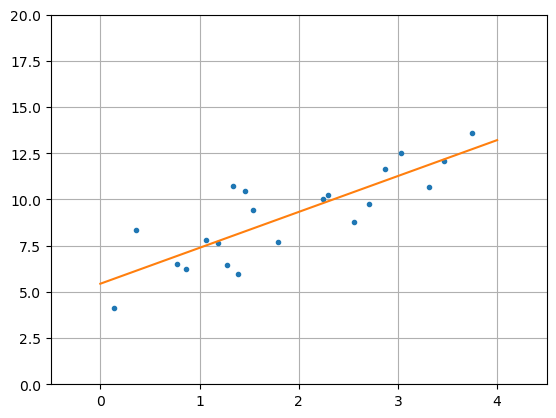

In [10]:
xs1 = np.linspace(0,4,10)
ys1 = beta01b + beta11b*xs1
plt.plot(x1,y1,'.',xs1,ys1)
plt.grid(True), plt.xlim([-0.5,4.5]), plt.ylim([0,20])
plt.show()

### Part 1c (2 marks)

Compute the residual sum of squares $\| \boldsymbol{y} - X \boldsymbol{\beta} \|^2$ for the optimial coefficients $\beta_0$ and $\beta_1$ computed in part 1b. Save the result as `RSS1c`.

In [11]:
# YOUR CODE HERE
RSS1c = np.sum((y1 - X @ beta)**2)

In [12]:
# Test 1: Verify RSS1c is a positive number. (1 mark)
assert RSS1c > 0
print("Test 1: Success!")

Test 1: Success!


In [13]:
# Test 2: Verify RSS1c is the correct value. This cell contains hidden tests. (1 mark)
assert np.round(RSS1c) == 37

## Problem 2: Normal Equations

Suppose we have 100 data points $(x_0,y_0),\dots,(x_{99},y_{99})$ and we construct the normal equations $X^TX \boldsymbol{\beta} = X^T \boldsymbol{y}$ such that:

$$
X^TX = \begin{bmatrix} 100.0 & 54.29 \\ 54.29 & 38.2755 \end{bmatrix}
\hspace{10mm}
X^T \boldsymbol{y} = \begin{bmatrix} 296.39508636 \\ 150.40322735 \end{bmatrix}
$$

### Part 2a (3 marks)

Compute the coefficients $\beta_0$ and $\beta_1$ of the linear model $y = \beta_0 + \beta_1 x + \varepsilon$ which best fits the data by computing the solution of the normal equations. Save the results as `beta02a` and `beta12a` respectively.

In [14]:
# YOUR CODE HERE
XTX = np.array([[100., 54.29], [54.29, 38.2755]])
XTy = np.array([[296.39508636],[150.40322735]])
beta2 = la.inv(XTX) @ XTy
beta02a = beta2[0]
beta12a = beta2[1]

In [15]:
# Test 1: Verify beta02a is positive and beta12a is negative. (1 mark)
assert beta02a > 0
assert beta12a < 0
print("Test 1: Success!")

Test 1: Success!


In [16]:
# Test 2: Verify beta02a is the correct value. This cell contains hidden tests. (1 mark)
assert np.round(beta02a) == 4.

In [17]:
# Test 3: Verify beta12a is the correct value. This cell contains hidden tests. (1 mark)
assert np.round(beta12a) == -1.

### Part 2b (4 marks)

Now suppose we add an additional data point $(0.545,2.871)$ to the dataset. Let $X_{2b}$ be the matrix with 101 rows with the added point $x_{100} = 0.545$ and let $\boldsymbol{y}_{2b}$ be the vector with added entry $y_{100} = 2.871$. Find the matrix $X_{2b}^T X_{2b}$, the vector $X_{2b}^T \boldsymbol{y}_{2b}$ and compute the vector of coefficients $\boldsymbol{\beta}_{2b}$. Save the results as `XTX2b`, `XTy2b` and `beta2b` respectively.

In [18]:
# YOUR CODE HERE
xnew = np.array([1, 0.545]).reshape(-1,1)
ynew = 2.871
XTX2b = XTX + xnew @ xnew.T 
XTy2b = XTy + xnew * ynew
beta2b = la.inv(XTX2b) @ XTy2b

In [19]:
# Test 1: Verify XTX2b, XTy2b and beta2b NumPy arrays. (1 mark)
assert isinstance(XTX2b,np.ndarray)
assert isinstance(XTy2b,np.ndarray)
assert isinstance(beta2b,np.ndarray)
print("Test 1: Success!")

Test 1: Success!


In [20]:
# Test 2: Verify XTX2b has correct entries. This cell contains hidden tests. (1 mark)
assert XTX2b[0,0] == 101.

In [21]:
# Test 3: Verify XTy2b has correct entries. This cell contains hidden tests. (1 mark)
assert np.round(XTy2b[0]) == 299.

In [22]:
# Test 4: Verify beta2b has correct entries. This cell contains hidden tests. (1 mark)
assert np.round(beta2b[0],1) == 3.6

## Problem 3: Multiple Linear Regression

Let us recall the formulation of multiple linear regression (see [MATH 360 > Data-Driven Models > Linear Regression](https://ubcmath.github.io/MATH360/data-driven/linear-regression/least-squares.html#normal-equations)). Consider $N+1$ data points $(\boldsymbol{x}_0,y_0),(\boldsymbol{x}_1,y_1),\dots,(\boldsymbol{x}_N,y_N)$ where each sample $\boldsymbol{x}_i = (x_{i,1},\dots,x_{i,p}) \in \mathbb{R}^p$ is a vector of $p$ independent variables. The linear model

$$
y = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p + \varepsilon
$$

that best fits the data is the solution to the normal equations

$$
X^T X \boldsymbol{\beta} = X^T \boldsymbol{y}
$$

where

$$
X = \begin{bmatrix} 1 & x_{0,1} & \cdots & x_{0,p} \\ 1 & x_{1,1} & \cdots & x_{1,p} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{N,1} & \cdots & x_{N,p} \end{bmatrix}
\hspace{10mm}
\boldsymbol{y} = \begin{bmatrix} y_0 \\ y_1 \\ \vdots \\ y_N \end{bmatrix}
\hspace{10mm}
\boldsymbol{\beta} = \begin{bmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p \end{bmatrix}
$$

The vector of coefficients $\boldsymbol{\beta}$ minimizes the residual sum of squares

$$
\| \boldsymbol{y} - X \boldsymbol{\beta} \|^2
$$

Consider the following data:

In [23]:
x13 = [2.95, 2.85, 0.75, 0.21, 2.25, 0.98, 3.09, 0.27, 2.94, 2.33, 3.42, 1.54, 3.03, 3.78, 0.28, 0.53, 2.98, 0.45, 1.79, 0.23]
x23 = [0.47, 0.89, 0.60, 0.87, 1.17, 0.61, 1.56, 1.37, 0.05, 1.00, 1.79, 1.23, 0.65, 1.91, 0.03, 0.65, 0.11, 0.79, 1.27, 1.64]
x33 = [3.69, 1.04, 3.91, 1.93, 0.91, 3.55, 4.23, 2.22, 3.16, 3.28, 0.58, 2.16, 0.38, 2.08, 3.79, 4.93, 2.60, 4.61, 4.38, 3.88]
y3  = [4.3,11.58,-5.94,-2.78,8.91,-3.86,4.31,-2.32,5.24,3.27,15.79,3.41,13.74,13.34,-8.06,-9.2,7.22,-8.59,-2.36,-6.86]

### Part 3a (2 marks)

Construct the matrix $X$ for the data `x13`, `x23` and `x33` above. Save the result as `X3a`.

In [24]:
# YOUR CODE HERE
X3a = np.column_stack((np.ones(len(x13)), x13, x23, x33))

In [25]:
# Test 1: Verify X3a is a 20 by 4 NumPy array. (1 mark)
assert isinstance(X3a,np.ndarray)
assert X3a.shape == (20,4)
print("Test 1: Success!")

Test 1: Success!


In [26]:
# Test 2: Verify X3a has correct entries. This cell contains hidden tests. (1 mark)
assert np.allclose(X3a[0,:],[1,2.95,0.47,3.69])

### Part 3b (2 marks)

Compute the coefficients $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ for the linear model that best fits the data by solving the normal equations. Save the coefficients as `beta03b`, `beta13b`, `beta23b` and `beta33b` respectively.

In [27]:
# YOUR CODE HERE
beta = la.inv(X3a.T @ X3a) @ X3a.T @ np.array(y3)
beta03b = beta[0]
beta13b = beta[1]
beta23b = beta[2]
beta33b = beta[3]

In [28]:
# Test 1: Verify beta03b, beta13b, beta23b are positive numbers and beta33b is negative. (1 mark)
assert beta03b > 0
assert beta13b > 0
assert beta23b > 0
assert beta33b < 0
print("Test 1: Success!")

Test 1: Success!


In [29]:
# Test 2: Verify beta03b, beta13b, beta23b, and beta33b are the correct values. This cell contains hidden tests. (1 mark)
assert np.round(beta03b) == 1
assert np.round(beta13b) == 4
assert np.round(beta23b) == 1
assert np.round(beta33b) == -3

### Part 3c (4 marks)

Contruct the vector of residuals $\boldsymbol{\varepsilon} = \boldsymbol{y} - X\boldsymbol{\beta}$ and the coefficient of determination $R^2$. Save the results as `res3c` and `R23c`.

In [30]:
# YOUR CODE HERE
res3c = y3 - (beta03b + beta13b*np.array(x13) + beta23b*np.array(x23) + beta33b*np.array(x33))
# r squared
R23c = 1 - np.sum(res3c**2)/np.sum((y3 - np.mean(y3))**2)

In [31]:
# Test 1: Verify R23c is between 0 and 1. (1 mark)
assert R23c > 0
assert R23c < 1
print("Test 1: Success!")

Test 1: Success!


In [32]:
# Test 2: Verify R23c is the correct value up to 14 decimal places. This cell contains hidden tests. (1 mark)
assert np.round(R23c,4) == 0.9992

In [33]:
# Test 3: Verify res3c is a NumPy array of length 20. (1 mark)
assert isinstance(res3c,np.ndarray)
assert np.size(res3c) == 20
print("Test 3: Success!")

Test 3: Success!


In [34]:
# Test 4: Verify res3c has the correct entries. This cell contains hidden tests. (1 mark)
assert np.abs(res3c[0] - 0.0435831177938617) < 1e-12

### Part 3d (1 mark)

We say that a linear regression model is a good representation of the data if the residuals are normally distributed with mean 0 and the residuals are independent of the independent variables and the index. The cell below plots the diagnostic plots for the residuals versus the independent variables and index:

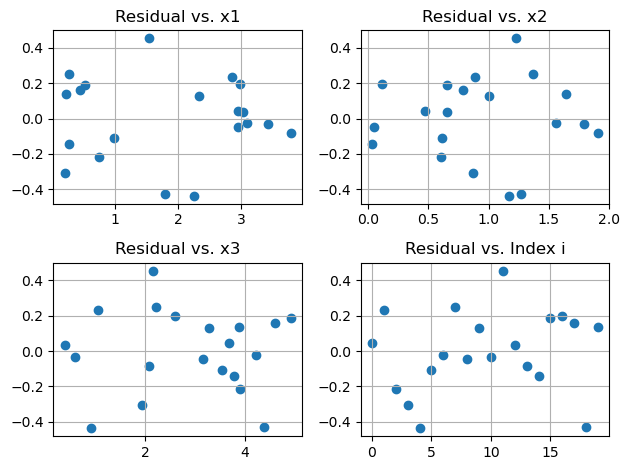

In [35]:
plt.subplot(2,2,1), plt.scatter(x13,res3c), plt.grid(True), plt.title('Residual vs. x1')
plt.subplot(2,2,2), plt.scatter(x23,res3c), plt.grid(True), plt.title('Residual vs. x2')
plt.subplot(2,2,3), plt.scatter(x33,res3c), plt.grid(True), plt.title('Residual vs. x3')
plt.subplot(2,2,4), plt.scatter(range(len(res3c)),res3c), plt.grid(True), plt.title('Residual vs. Index i')
plt.tight_layout()
plt.show()

Do the diagnostic plots show that the residuals are independent of $x_1$, $x_2$, $x_3$ and the index $i$? Enter your response as `True` or `False` and save the value as `diagnostic3d`.

In [36]:
# YOUR CODE HERE
diagnostic3d = True

In [37]:
# Test 1: Verify diagnostic3d is the correct value. This cell contains hidden tests. (1 mark)
assert isinstance(diagnostic3d,bool)

## Problem 4: Logistic Regression

See [MATH 360 > Logistic Regression](https://ubcmath.github.io/MATH360/data-driven/logistic-regression/index.html) for examples of logistic regression. Consider the following data:

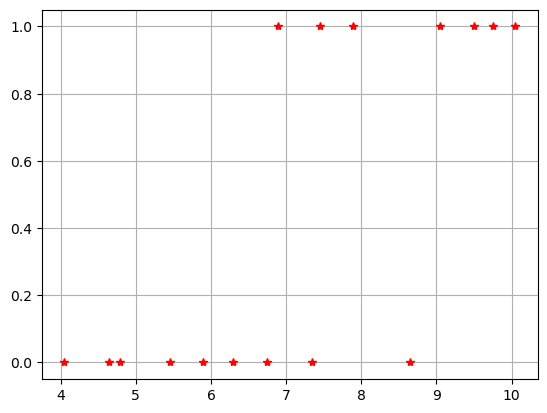

In [38]:
x4 = [4.05,4.65,4.79,5.45,5.89,6.30,6.75,6.89,7.35,7.45,7.89,8.65,9.05,9.50,9.75,10.05]
y4 = [0,0,0,0,0,0,0,1,0,1,1,0,1,1,1,1]
plt.plot(x4,y4,'r*')
plt.grid(True)
plt.show()

### Part 4a (3 marks)

Fit a logistic regression model $y = \sigma(x;W,b)$ using a **cross entropy** cost function **without** regularization ($\alpha=0$). Save the optimal values $W$ and $b$ as `W4a` and `b4a` respectively.  

In [39]:
# YOUR CODE HERE
sigma = lambda x,W,b: 1/(1 + np.exp(-(W*x + b)))
costCE = lambda W,b,x,y: -1/len(y)*np.sum(y*np.log(sigma(x,W,b)) + (1 - y)*np.log(1 - sigma(x,W,b)))

x4 = np.array(x4)
y4 = np.array(y4)

F = lambda z: costCE(z[0],z[1], x4, y4)
opt = minimize(F, np.array([0.,0.]))
W4a, b4a = opt.x

In [40]:
# Test 1: Verify W4a is positive and b4a is a negative number. (1 mark)
assert W4a > 0
assert b4a < 0
print("Test 1: Success!")

Test 1: Success!


In [41]:
# Test 2: Verify W4a is the correct value. This cell contains hidden tests. (1 mark)
assert np.round(W4a,1) == 1.4

In [42]:
# Test 3: Verify b4a is the correct value. This cell contains hidden tests. (1 mark)
assert np.round(b4a,1) == -10.6

Plot the logistic regression model with the data:

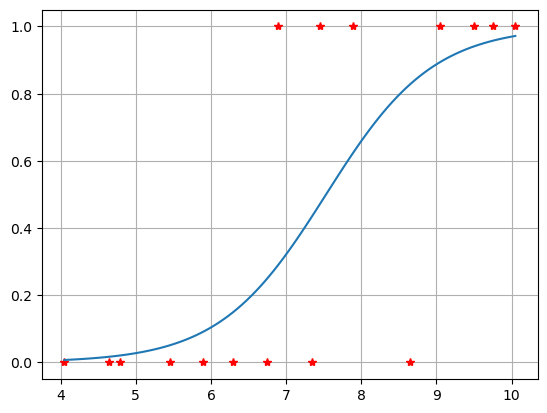

In [43]:
xs4 = np.linspace(min(x4),max(x4),100)
ys4 = 1/(1 + np.exp(-(W4a*xs4 + b4a)))
plt.plot(x4,y4,'r*'), plt.plot(xs4,ys4)
plt.grid(True)
plt.show()

## Part 4b (1 mark)

Suppose we observe $x=7.8$. Does the model computed in part 4a predict $y=0$ or $y=1$? Save the results as `y4b`.

In [44]:
# YOUR CODE HERE
y4b = np.round(1/(1 + np.exp(-(W4a*7.8 + b4a))), 0)
y4b

1.0

In [45]:
# Test 1: Verify y4a is the correct value. This cell contains hidden tests. (1 mark)
assert y4b == 0 or y4b == 1

## Problem 5: Logistic Regression with Regularization

We can use `LogisticRegression` in the `sklearn` package to compute logistic regression models. Note that the parameter $C$ in `LogisticRegression` corresponds to 

$$
C = \frac{1}{2 S \alpha}
$$

where $\alpha$ is the regularization parameter in our formulation (see [MATH 360 > Multivariable Logistic Regression](https://ubcmath.github.io/MATH360/data-driven/logistic-regression/multivariable.html#cross-entropy)) and $S$ is the number of samples in the training set (see [scikit-learn > Linear Models > Logistic Regression](https://scikit-learn.org/stable/modules/linear_model.html#binary-case)).

Consider the following data:

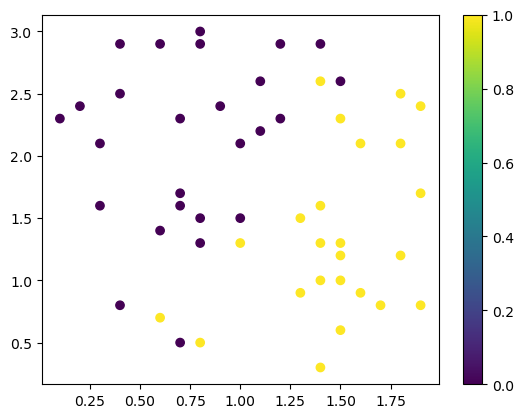

In [46]:
x05 = [1.6, 0.7, 0.8, 1.5, 1. , 1.2, 0.7, 1.4, 1.4, 1.3, 0.4, 1.1, 1.9, 0.8, 1.5, 0.7, 1.4, 0.4, 0.1, 1.9, 1.5, 0.6, 1.8, 0.8, 1.2, 0.7, 0.4, 0.3, 0.3, 1. , 1.5, 1.3, 0.8, 1.5, 0.6, 1.4, 1.5, 1. , 1.4, 0.6, 1.9, 1.1, 1.4, 0.9, 1.7, 1.8, 0.8, 1.8, 0.2, 1.6]
x15 = [0.9, 1.6, 3. , 0.6, 1.3, 2.9, 2.3, 1.6, 2.6, 0.9, 0.8, 2.2, 2.4, 1.5, 1.2, 1.7, 1.3, 2.5, 2.3, 0.8, 2.6, 0.7, 2.1, 2.9, 2.3, 0.5, 2.9, 1.6, 2.1, 1.5, 1. , 1.5, 0.5, 1.3, 2.9, 2.9, 2.3, 2.1, 0.3, 1.4, 1.7, 2.6, 1. , 2.4, 0.8, 2.5, 1.3, 1.2, 2.4, 2.1]
y5  = [ 1.,  0.,  0.,  1.,  1.,  0.,  0.,  1.,  1.,  1.,  0.,  0.,  1.,  0.,  1.,  0.,  1.,  0.,  0.,  1.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,  0.,  0.,  1.,  0.,  1.,  0.,  1.,  0.,  1.,  0.,  1.,  1.,  0.,  1.,  0.,  1.]

plt.scatter(x05,x15,c=y5)
plt.colorbar()
plt.show()

### Part 5a (2 marks)

Use `LogisticRegression` with regularization parameter $\alpha = 0.01$ to compute the linear regression model. Use `max_iter=1000`. Save the optimal parameters $W_0$, $W_1$ and $b$ as `W05a`, `W15a`, `b5` respectively.

In [47]:
# YOUR CODE HERE
X = np.column_stack((x05, x15))
model = LogisticRegression(C = 1/(2*len(y5)*0.01), max_iter=1000).fit(X, y5)
W05a, W15a = model.coef_[0]
b5a = b5 = model.intercept_[0]

In [48]:
# Test 1: Verify W05a is positive and W15a is a negative number. (1 mark)
assert W05a > 0
assert W15a < 0
print("Test 1: Success!")

Test 1: Success!


In [49]:
# Test 2: Verify W05a and W15a are the correct values. This cell contains hidden tests. (1 mark)
assert np.round(W05a) == 3
assert np.round(W15a) == -1

Plot the logistic model with the data: 

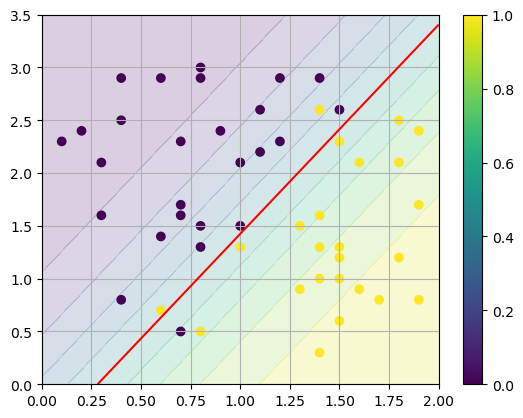

In [50]:
x0 = np.linspace(0,2,50); x1 = np.linspace(0,3.5,50);
X0,X1 = np.meshgrid(x0,x1)
Y = 1/(1 + np.exp(-(W05a*X0 + W15a*X1 + b5a)))
plt.contourf(X0,X1,Y,levels=np.arange(0,1.1,0.1),alpha=0.2)
plt.contour(X0,X1,Y,levels=[0.5],colors='r')
plt.grid(True)
plt.scatter(x05,x15,c=y5)
plt.colorbar()
plt.show()

### Part 5b (2 marks)

Use `LogisticRegression` with smaller and smaller values of the regularization parameter $\alpha$ to compute the linear regression model (always using `max_iter=1000`). Compute the cross entropy (see function `costCE` included below) for each model and observe the results. Approximate the lower bound on the cross entropy up to 4 decimal places. Save the result as `CE5b`.

In [51]:
def costCE(W,b,X,y):
    N,p = X.shape
    W = np.array(W).reshape(p,1)
    y = np.array(y).reshape(N,1)
    S = 1/(1 + np.exp(-(X@W + b)))
    L = -1/N*np.sum(y*np.log(S) + (1 - y)*np.log(1 - S))
    return L

<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_48597/1735664199.py:15: SyntaxWarning: invalid escape sequence '\l'
  plt.grid(True), plt.colorbar(label='$\log_{10}(alpha)$')


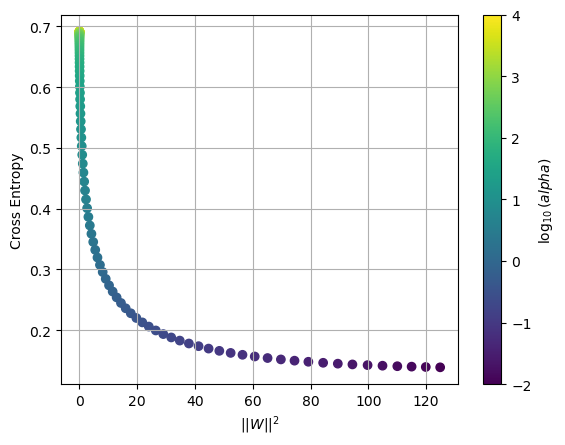

In [52]:
# YOUR CODE HERE
CEs = []
Rs = []
alphas = np.logspace(4, -2, 100)
for alpha in alphas:
    model = LogisticRegression(C=1/alpha, max_iter=1000).fit(X,y5)
    W = model.coef_
    b = model.intercept_
    CE = costCE(W,b,X,y5)
    R = np.linalg.norm(W)**2
    CEs.append(CE)
    Rs.append(R)

plt.scatter(Rs,CEs,c=np.log10(alphas))
plt.grid(True), plt.colorbar(label='$\log_{10}(alpha)$')
plt.xlabel('$|| W ||^2$')
plt.ylabel('Cross Entropy')
plt.show()

In [53]:
CE5b = round(min(CEs),4)
CE5b

0.1387

In [54]:
# Test 1: Verify CE5b is between 0 and 1. (1 mark)
assert CE5b > 0
assert CE5b < 1
print("Test 1: Success!")

Test 1: Success!


In [55]:
# Test 2: Verify CE5b is the correct value. This cell contains hidden tests. (1 mark)
assert np.round(CE5b,2) == 0.14